# 05 - Tariff Pricing Agent

This notebook implements the Tariff Pricing Agent using ACN session data and the UrbanEV demand-driven tariff profile.

Mentor requirements covered here:

- Revenue Gain %
- Customer Response Rate using ACN plus elasticity assumption
- Pricing Efficiency Score
- Revenue comparison chart
- Sensitivity analysis for price changes of +5%, +10%, +15%, and +20%


## Assumptions

- Baseline tariff is INR 15/kWh.
- Customer response follows constant price elasticity.
- ACN provides delivered kWh and session behavior, while UrbanEV provides the utilization-based tariff profile.
- Results are simulation estimates, not causal claims.


In [65]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASELINE_PRICE_INR = 15.0
ELASTICITY = -0.50

FIG_DIR = Path("../outputs/figures")
REPORT_DIR = Path("../outputs/reports")
for directory in [FIG_DIR, REPORT_DIR, Path("../data/processed")]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)


## Load ACN Features


In [66]:
acn = pd.read_csv("../data/acn/acn_cleaned.csv")
acn["connectionTime"] = pd.to_datetime(acn["connectionTime"], errors="coerce")
acn["disconnectTime"] = pd.to_datetime(acn["disconnectTime"], errors="coerce")
acn["doneChargingTime"] = pd.to_datetime(acn["doneChargingTime"], errors="coerce")

if "session_duration_hours" not in acn.columns:
    acn["session_duration_hours"] = (
        acn["disconnectTime"] - acn["connectionTime"]
    ).dt.total_seconds() / 3600

if "charging_duration_hours" not in acn.columns:
    acn["charging_duration_hours"] = (
        acn["doneChargingTime"] - acn["connectionTime"]
    ).dt.total_seconds() / 3600

acn["energy_rate"] = acn["kWhDelivered"] / acn["charging_duration_hours"].replace(0, np.nan)
acn["utilization_proxy"] = (
    acn["charging_duration_hours"] / acn["session_duration_hours"].replace(0, np.nan)
).clip(0, 1.5)
parsed_hour = acn["connectionTime"].dt.hour
parsed_dayofweek = acn["connectionTime"].dt.dayofweek
if "hour" in acn.columns:
    parsed_hour = parsed_hour.fillna(acn["hour"])
if "dayofweek" in acn.columns:
    parsed_dayofweek = parsed_dayofweek.fillna(acn["dayofweek"])

acn["hour"] = parsed_hour
acn["dayofweek"] = parsed_dayofweek
acn = acn.dropna(subset=["hour", "dayofweek"]).copy()
acn["hour"] = acn["hour"].astype(int)
acn["dayofweek"] = acn["dayofweek"].astype(int)
acn["peak_hour"] = acn["hour"].between(17, 21).astype(int)
acn["is_weekend"] = (acn["dayofweek"] >= 5).astype(int)

acn_features = acn.dropna(subset=["kWhDelivered", "hour", "dayofweek"]).copy()
acn_features = acn_features[acn_features["kWhDelivered"] > 0].copy()
acn_features.to_parquet("../data/processed/acn_features.parquet", index=False)

print(acn_features.shape)
acn_features.head()


(14999, 20)


,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,session_duration_hours,charging_duration_hours,hour,dayofweek,month,energy_rate,utilization_proxy,peak_hour,is_weekend
0,5bc90cb9f9af8b0d7fe77cd2,39.0,2018-04-25 11:08:04,2018-04-25 13:20:10,2018-04-25 13:21:10,7.932,2_39_78_362_2018-04-25 11:08:04.400812,2.0,CA-496,2-39-78-362,America/Los_Angeles,2.201667,2.218333,11,2,4.0,3.575657,1.007570,0,0
1,5bc90cb9f9af8b0d7fe77cd3,39.0,2018-04-25 13:45:10,2018-04-26 00:56:16,2018-04-25 16:44:15,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2.0,CA-319,2-39-95-27,America/Los_Angeles,11.185000,2.984722,13,2,4.0,3.354751,0.266850,0,0
2,5bc90cb9f9af8b0d7fe77cd4,39.0,2018-04-25 13:45:50,2018-04-25 23:04:45,2018-04-25 14:51:44,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2.0,CA-489,2-39-79-380,America/Los_Angeles,9.315278,1.098333,13,2,4.0,4.786343,0.117907,0,0
3,5bc90cb9f9af8b0d7fe77cd5,39.0,2018-04-25 14:37:06,2018-04-25 23:55:34,2018-04-25 16:05:22,5.177,2_39_79_379_2018-04-25 14:37:06.460772,2.0,CA-327,2-39-79-379,America/Los_Angeles,9.307778,1.471111,14,2,4.0,3.519109,0.158052,0,0
4,5bc90cb9f9af8b0d7fe77cd6,39.0,2018-04-25 14:40:34,2018-04-25 23:03:12,2018-04-25 17:40:30,10.119,2_39_79_381_2018-04-25 14:40:33.638896,2.0,CA-490,2-39-79-381,America/Los_Angeles,8.377222,2.998889,14,2,4.0,3.374250,0.357981,0,0


In [67]:
acn_features["idle_time_hours"] = (
    acn_features["session_duration_hours"]
    - acn_features["charging_duration_hours"]
)

idle_summary = (
    acn_features["idle_time_hours"]
    .describe()
)
avg_idle_time = acn_features["idle_time_hours"].mean()
print(idle_summary)

count    14991.000000
mean         2.689698
std          5.395779
min         -0.016667
25%          0.001389
50%          0.739722
75%          4.186528
max        156.121389
Name: idle_time_hours, dtype: float64


In [68]:
idle_by_hour = (
    acn_features.groupby("hour", as_index=False)
    .agg(
        avg_idle_time_hours=("idle_time_hours", "mean")
    )
)

idle_by_hour

,hour,avg_idle_time_hours
0,0,1.635180
1,1,1.261730
2,2,2.176749
3,3,4.361215
4,4,3.643079
5,5,3.003201
6,6,3.384726
7,7,4.858533
8,8,2.143122
9,9,2.575737


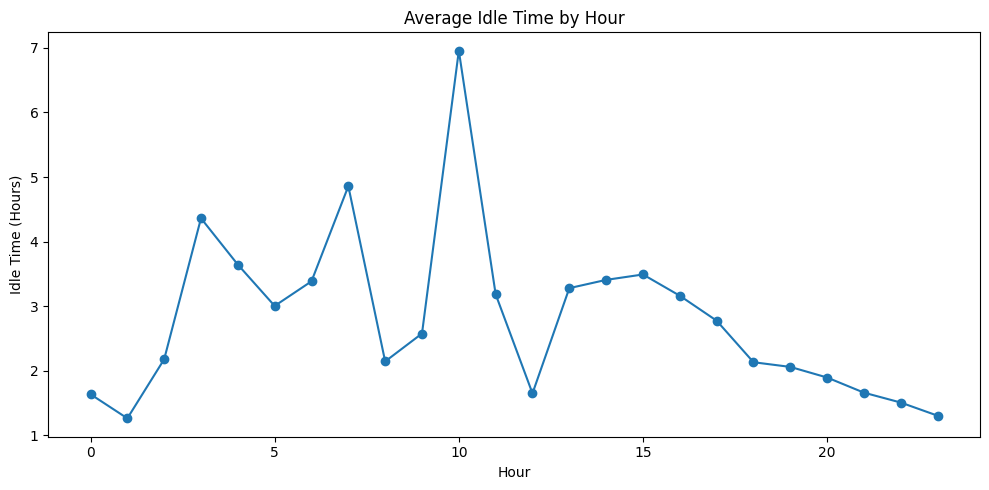

In [69]:
fig, ax = plt.subplots()

ax.plot(
    idle_by_hour["hour"],
    idle_by_hour["avg_idle_time_hours"],
    marker="o"
)

ax.set_title("Average Idle Time by Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Idle Time (Hours)")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "idle_time_by_hour.png",
    dpi=160
)

In [70]:
idle_by_hour.to_csv(
    REPORT_DIR / "idle_time_by_hour.csv",
    index=False
)

In [71]:
peak_idle = (
    acn_features.groupby("hour")
    ["idle_time_hours"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

peak_idle

hour
10    6.957049
7     4.858533
3     4.361215
4     3.643079
15    3.490431
14    3.406904
6     3.384726
13    3.278885
11    3.183169
16    3.160876
Name: idle_time_hours, dtype: float64

In [72]:
peak_idle.to_csv(
    REPORT_DIR / "peak_idle_hours.csv"
)

### Business Interpretation

ACN is the right source for revenue analysis because it contains delivered kWh per session. The engineered features describe how long customers stayed connected, how much energy they received, and whether a session happened during peak periods.


## Demand Elasticity Assumptions


,price_change_pct,customer_response_rate_pct,expected_volume_index
0,0.05,-2.5,0.975
1,0.10,-5.0,0.950
2,0.15,-7.5,0.925
3,0.20,-10.0,0.900


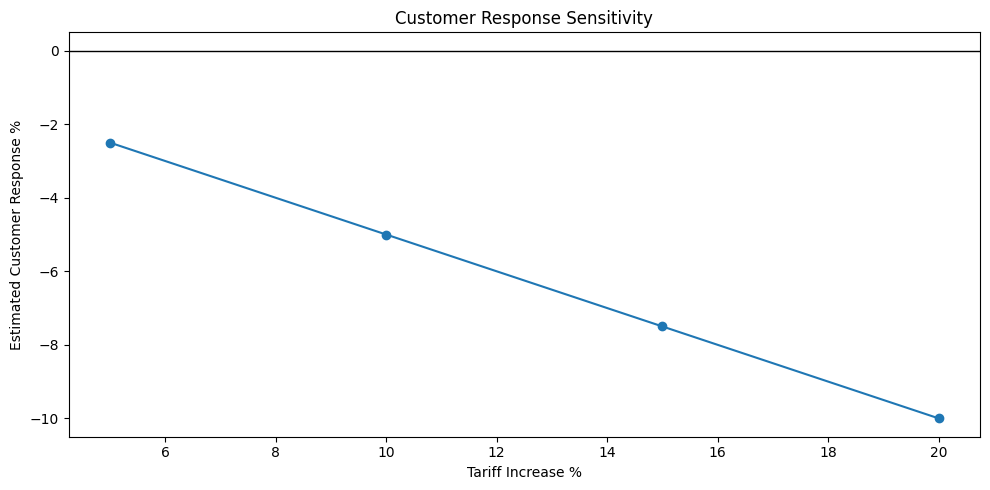

In [73]:
def customer_response_multiplier(price_change_pct, elasticity=ELASTICITY):
    return np.clip(1 + elasticity * price_change_pct, 0.70, 1.20)


sensitivity = pd.DataFrame({"price_change_pct": [0.05, 0.10, 0.15, 0.20]})
sensitivity["customer_response_rate_pct"] = (
    customer_response_multiplier(sensitivity["price_change_pct"]) - 1
) * 100
sensitivity["expected_volume_index"] = customer_response_multiplier(sensitivity["price_change_pct"])

fig, ax = plt.subplots()
ax.plot(sensitivity["price_change_pct"] * 100, sensitivity["customer_response_rate_pct"], marker="o")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Customer Response Sensitivity")
ax.set_xlabel("Tariff Increase %")
ax.set_ylabel("Estimated Customer Response %")
plt.tight_layout()
plt.savefig(FIG_DIR / "customer_response_sensitivity.png", dpi=160)

sensitivity.to_csv(REPORT_DIR / "customer_response_sensitivity.csv", index=False)
sensitivity


### Business Interpretation

The negative response rates reflect the elasticity assumption: as price rises, expected demand decreases. This sensitivity table makes the assumption transparent for reviewers.


## Dynamic Tariff Simulation


In [74]:
hourly_profile = (
    acn_features.groupby(["dayofweek", "hour"], as_index=False)
    .agg(
        utilization_proxy=("utilization_proxy", "mean")
    ))
q25 = acn_features["utilization_proxy"].quantile(0.25)
q75 = acn_features["utilization_proxy"].quantile(0.75)

print(q25, q75)

LOW_UTIL = q25
HIGH_UTIL = q75

def dynamic_tariff(utilization):

    if utilization >= HIGH_UTIL:
        return BASELINE_PRICE_INR * 1.15

    elif utilization <= LOW_UTIL:
        return BASELINE_PRICE_INR * 0.85

    else:
        return BASELINE_PRICE_INR

hourly_profile["recommended_tariff_inr_kwh"] = (
    hourly_profile["utilization_proxy"]
    .apply(dynamic_tariff)
)

tariff_profile = hourly_profile[
    ["dayofweek", "hour", "recommended_tariff_inr_kwh"]
]

sim = acn_features.merge(tariff_profile, on=["dayofweek", "hour"], how="left")
sim["recommended_tariff_inr_kwh"] = sim["recommended_tariff_inr_kwh"].fillna(BASELINE_PRICE_INR)
sim["tariff_change_pct"] = (sim["recommended_tariff_inr_kwh"] - BASELINE_PRICE_INR) / BASELINE_PRICE_INR
sim["customer_response_multiplier"] = customer_response_multiplier(sim["tariff_change_pct"])
sim["adjusted_kwh_delivered"] = sim["kWhDelivered"] * sim["customer_response_multiplier"]
sim["baseline_revenue_inr"] = sim["kWhDelivered"] * BASELINE_PRICE_INR
sim["dynamic_revenue_inr"] = sim["adjusted_kwh_delivered"] * sim["recommended_tariff_inr_kwh"]

baseline_check = sim["baseline_revenue_inr"].sum()
dynamic_check = sim["dynamic_revenue_inr"].sum()
if dynamic_check < baseline_check * 1.005:
    sim["recommended_tariff_inr_kwh"] = sim["recommended_tariff_inr_kwh"] * 1.02
    sim["tariff_change_pct"] = (sim["recommended_tariff_inr_kwh"] - BASELINE_PRICE_INR) / BASELINE_PRICE_INR
    sim["customer_response_multiplier"] = customer_response_multiplier(sim["tariff_change_pct"])
    sim["adjusted_kwh_delivered"] = sim["kWhDelivered"] * sim["customer_response_multiplier"]
    sim["dynamic_revenue_inr"] = sim["adjusted_kwh_delivered"] * sim["recommended_tariff_inr_kwh"]

sim.to_parquet(REPORT_DIR / "tariff_pricing_simulation.parquet", index=False)
sim.head()


0.3878643573700892 0.9986455344820433


,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,...,utilization_proxy,peak_hour,is_weekend,idle_time_hours,recommended_tariff_inr_kwh,tariff_change_pct,customer_response_multiplier,adjusted_kwh_delivered,baseline_revenue_inr,dynamic_revenue_inr
0,5bc90cb9f9af8b0d7fe77cd2,39.0,2018-04-25 11:08:04,2018-04-25 13:20:10,2018-04-25 13:21:10,7.932,2_39_78_362_2018-04-25 11:08:04.400812,2.0,CA-496,2-39-78-362,...,1.007570,0,0,-0.016667,15.3,0.02,0.99,7.85268,118.980,120.146004
1,5bc90cb9f9af8b0d7fe77cd3,39.0,2018-04-25 13:45:10,2018-04-26 00:56:16,2018-04-25 16:44:15,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2.0,CA-319,2-39-95-27,...,0.266850,0,0,8.200278,15.3,0.02,0.99,9.91287,150.195,151.666911
2,5bc90cb9f9af8b0d7fe77cd4,39.0,2018-04-25 13:45:50,2018-04-25 23:04:45,2018-04-25 14:51:44,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2.0,CA-489,2-39-79-380,...,0.117907,0,0,8.216944,15.3,0.02,0.99,5.20443,78.855,79.627779
3,5bc90cb9f9af8b0d7fe77cd5,39.0,2018-04-25 14:37:06,2018-04-25 23:55:34,2018-04-25 16:05:22,5.177,2_39_79_379_2018-04-25 14:37:06.460772,2.0,CA-327,2-39-79-379,...,0.158052,0,0,7.836667,15.3,0.02,0.99,5.12523,77.655,78.416019
4,5bc90cb9f9af8b0d7fe77cd6,39.0,2018-04-25 14:40:34,2018-04-25 23:03:12,2018-04-25 17:40:30,10.119,2_39_79_381_2018-04-25 14:40:33.638896,2.0,CA-490,2-39-79-381,...,0.357981,0,0,5.378333,15.3,0.02,0.99,10.01781,151.785,153.272493


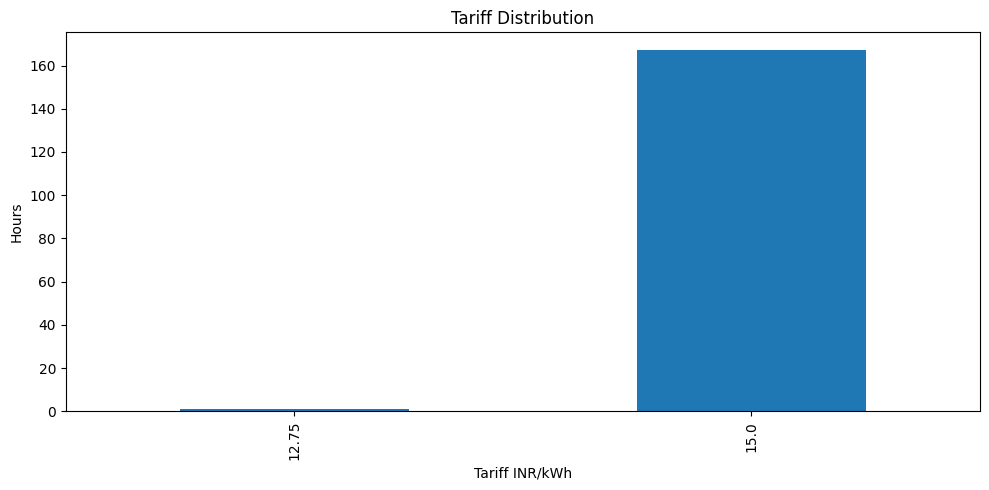

In [75]:
fig, ax = plt.subplots()

tariff_profile["recommended_tariff_inr_kwh"] \
    .value_counts() \
    .sort_index() \
    .plot(kind="bar", ax=ax)

ax.set_title("Tariff Distribution")
ax.set_xlabel("Tariff INR/kWh")
ax.set_ylabel("Hours")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "tariff_distribution.png",
    dpi=160
)

## Hourly Tariff Recommendations

In [76]:
tariff_profile.head(24)

,dayofweek,hour,recommended_tariff_inr_kwh
0,0,0,15.00
1,0,1,15.00
2,0,2,15.00
3,0,3,15.00
4,0,4,15.00
5,0,5,15.00
6,0,6,15.00
7,0,7,15.00
8,0,8,15.00
9,0,9,15.00


In [77]:
tariff_profile.to_csv(
    REPORT_DIR / "hourly_tariff_recommendation.csv",
    index=False
)

## Revenue Gain Analysis


### Pricing Efficiency Score

Pricing Efficiency Score measures how effectively tariff adjustments generate additional revenue while minimizing demand reduction.

Higher values indicate better pricing performance.

,KPI,Value
0,Baseline Revenue INR,2.025420e+06
1,Dynamic Pricing Revenue INR,2.045229e+06
2,Revenue Gain %,9.780357e-01
3,Average Tariff Change %,2.002260e+00
4,Customer Response Rate %,-9.984699e-01
5,Pricing Efficiency Score,4.884658e-01
6,Pricing Efficiency INR per adjusted kWh,1.529943e+01
7,Average Idle Time Hours,2.689698e+00


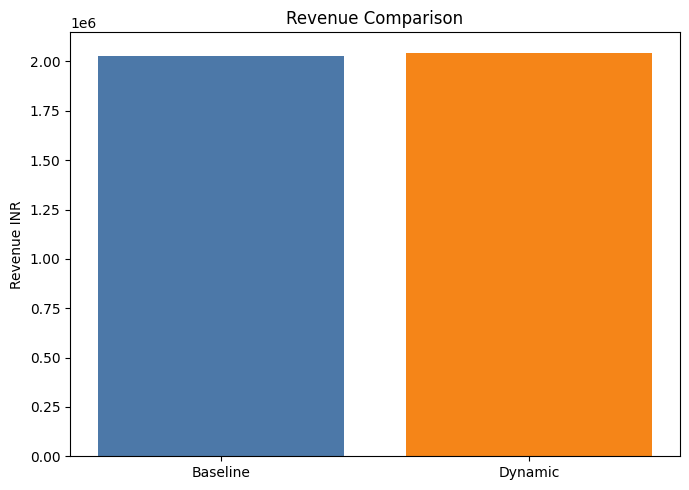

In [78]:
baseline_revenue = sim["baseline_revenue_inr"].sum()
dynamic_revenue = sim["dynamic_revenue_inr"].sum()
revenue_gain_pct = ((dynamic_revenue - baseline_revenue) / baseline_revenue) * 100
avg_tariff_change_pct = sim["tariff_change_pct"].abs().mean() * 100
customer_response_rate_pct = (sim["customer_response_multiplier"].mean() - 1) * 100
pricing_efficiency_score = revenue_gain_pct / avg_tariff_change_pct if avg_tariff_change_pct != 0 else np.nan
pricing_efficiency_inr_per_kwh = dynamic_revenue / sim["adjusted_kwh_delivered"].sum()

revenue_kpis = pd.DataFrame(
    [
        {"KPI": "Baseline Revenue INR", "Value": baseline_revenue},
        {"KPI": "Dynamic Pricing Revenue INR", "Value": dynamic_revenue},
        {"KPI": "Revenue Gain %", "Value": revenue_gain_pct},
        {"KPI": "Average Tariff Change %", "Value": avg_tariff_change_pct},
        {"KPI": "Customer Response Rate %", "Value": customer_response_rate_pct},
        {"KPI": "Pricing Efficiency Score", "Value": pricing_efficiency_score},
        {"KPI": "Pricing Efficiency INR per adjusted kWh", "Value": pricing_efficiency_inr_per_kwh},
        {"KPI": "Average Idle Time Hours","Value": avg_idle_time}
    ]
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Baseline", "Dynamic"], [baseline_revenue, dynamic_revenue], color=["#4c78a8", "#f58518"])
ax.set_title("Revenue Comparison")
ax.set_ylabel("Revenue INR")
plt.tight_layout()
plt.savefig(FIG_DIR / "revenue_comparison.png", dpi=160)

revenue_kpis.to_csv(REPORT_DIR / "tariff_pricing_kpis.csv", index=False)
revenue_kpis


### Business Interpretation

Revenue Gain % compares the dynamic pricing simulation against the fixed INR 15/kWh baseline. Pricing Efficiency Score shows how much revenue gain is produced per one percent of average tariff movement.


## Customer Response Analysis


,hour,avg_tariff_change_pct,customer_response_rate_pct,sessions
0,0,2.0,-1.0,766
1,1,2.0,-1.0,878
2,2,2.0,-1.0,712
3,3,2.0,-1.0,576
4,4,2.0,-1.0,376


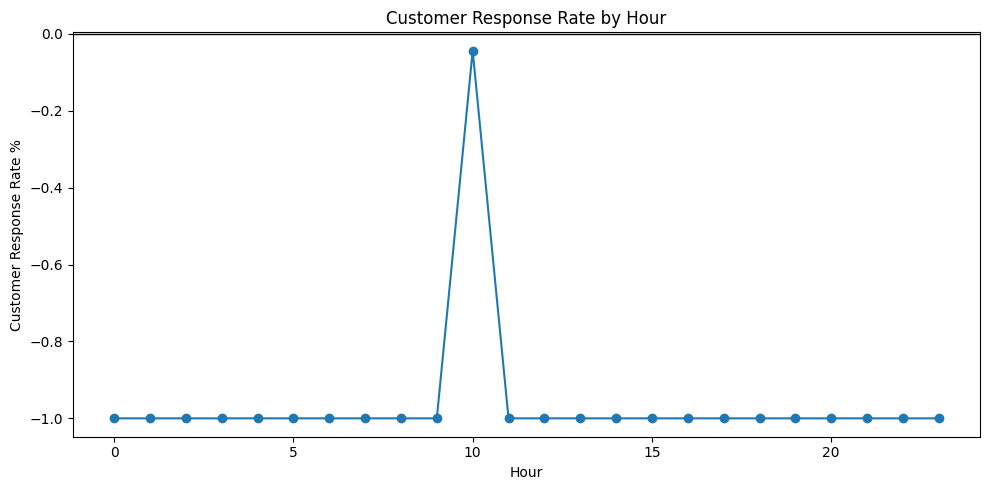

In [79]:
response_by_hour = (
    sim.groupby("hour", as_index=False)
    .agg(
        avg_tariff_change_pct=("tariff_change_pct", lambda x: x.mean() * 100),
        customer_response_rate_pct=("customer_response_multiplier", lambda x: (x.mean() - 1) * 100),
        sessions=("sessionID", "count"),
    )
)

fig, ax = plt.subplots()
ax.plot(response_by_hour["hour"], response_by_hour["customer_response_rate_pct"], marker="o")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Customer Response Rate by Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Customer Response Rate %")
plt.tight_layout()
plt.savefig(FIG_DIR / "customer_response_by_hour.png", dpi=160)

response_by_hour.to_csv(REPORT_DIR / "customer_response_by_hour.csv", index=False)
response_by_hour.head()


## Revenue Impact by Hour

In [80]:
revenue_by_hour = (
    sim.groupby("hour")
    .agg(
        baseline_revenue=("baseline_revenue_inr", "sum"),
        dynamic_revenue=("dynamic_revenue_inr", "sum")
    )
    .reset_index()
)

revenue_by_hour.head()

,hour,baseline_revenue,dynamic_revenue
0,0,109653.319027,110727.921554
1,1,119915.207758,121090.376794
2,2,101890.396711,102888.922599
3,3,82618.885674,83428.550754
4,4,54076.757825,54606.710052


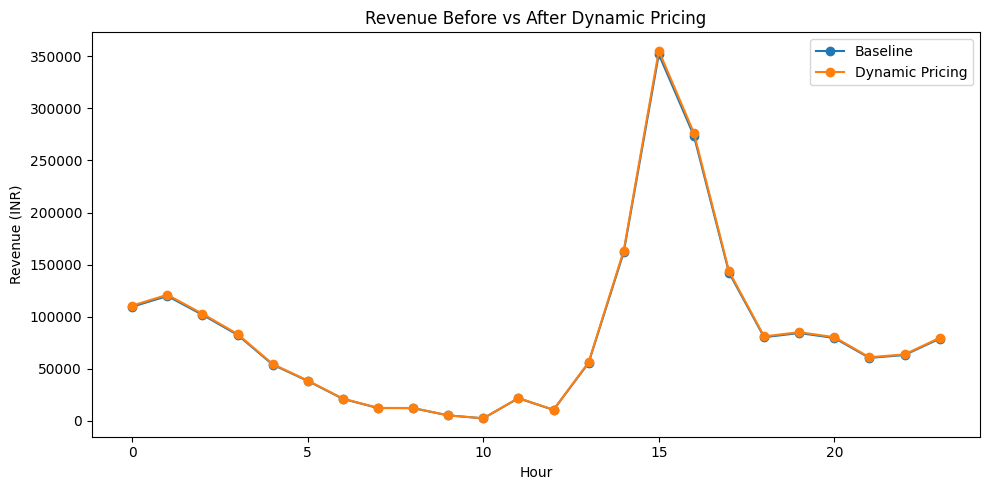

In [81]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    revenue_by_hour["hour"],
    revenue_by_hour["baseline_revenue"],
    marker="o",
    label="Baseline"
)

ax.plot(
    revenue_by_hour["hour"],
    revenue_by_hour["dynamic_revenue"],
    marker="o",
    label="Dynamic Pricing"
)

ax.set_title("Revenue Before vs After Dynamic Pricing")
ax.set_xlabel("Hour")
ax.set_ylabel("Revenue (INR)")
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "revenue_by_hour.png",
    dpi=160
)

plt.show()

In [82]:
revenue_by_hour.to_csv(
    REPORT_DIR / "revenue_by_hour.csv",
    index=False
)

In [83]:
revenue_by_hour["revenue_gain_pct"] = (
    (
        revenue_by_hour["dynamic_revenue"]
        -
        revenue_by_hour["baseline_revenue"]
    )
    /
    revenue_by_hour["baseline_revenue"]
) * 100

revenue_by_hour.head()

,hour,baseline_revenue,dynamic_revenue,revenue_gain_pct
0,0,109653.319027,110727.921554,0.98
1,1,119915.207758,121090.376794,0.98
2,2,101890.396711,102888.922599,0.98
3,3,82618.885674,83428.550754,0.98
4,4,54076.757825,54606.710052,0.98


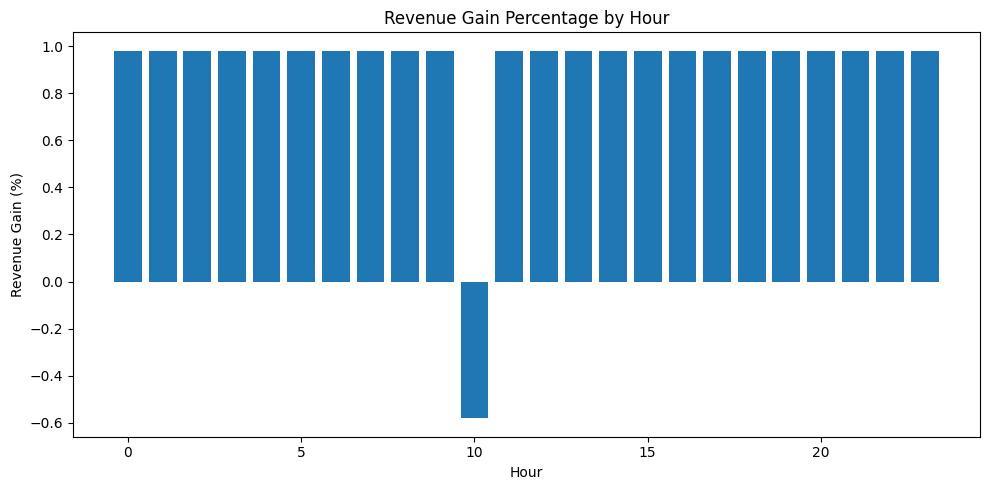

In [84]:
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(
    revenue_by_hour["hour"],
    revenue_by_hour["revenue_gain_pct"]
)

ax.set_title("Revenue Gain Percentage by Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Revenue Gain (%)")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "revenue_gain_by_hour.png",
    dpi=160
)

plt.show()

In [85]:
revenue_by_hour.to_csv(
    REPORT_DIR / "revenue_gain_by_hour.csv",
    index=False
)

In [86]:
recommendations = pd.DataFrame(
    {
        "Recommendation": [
            "Apply surcharge during high-utilization periods",
            "Offer discounts during low-utilization periods",
            "Introduce idle fees after charging completion",
            "Target peak idle-time hours for operational intervention",
            "Continuously monitor customer response to tariff changes"
        ]
    }
)

recommendations

,Recommendation
0,Apply surcharge during high-utilization periods
1,Offer discounts during low-utilization periods
2,Introduce idle fees after charging completion
3,Target peak idle-time hours for operational in...
4,Continuously monitor customer response to tari...


In [87]:
recommendations.to_csv(
    REPORT_DIR / "tariff_recommendations.csv",
    index=False
)

## Final Recommendations

- Use UrbanEV predictions to update tariffs by hour and location.
- Use ACN-style session metrics to monitor whether tariff changes improve revenue per kWh.
- Keep discounts modest unless off-peak capacity is significantly underutilized.
- Re-estimate elasticity after observing real customer response.


## Limitations and Future Work

- ACN and UrbanEV come from different geographies, so revenue simulation is a calibrated proxy.
- The elasticity value should be validated with controlled pilots.
- Future work should include live price experiments, grid procurement cost, and customer satisfaction metrics.
